# 04 — Y2Y corridor-wide results (one run at a time)

Results analysis for the corridor-wide run (`config.ANALYSES["y2y"]`), over the shared `results_core.py` engine. Benchmark = the 6 featured parks + the Ross River IPCA. **Kernel:** `.venv` (Python). Ethan runs cell-by-cell.

In [ ]:
# ---- Setup: shared results engine + WHICH SOLVE TO ANALYSE ---------------
import sys, pathlib
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
sys.path.insert(0, str(_cands[0]))

import importlib
import results_core as rc, config
importlib.reload(config); importlib.reload(rc)

ANALYSIS = "y2y"            # <-- the ONLY line that differs between 04a / 04b / 04c

# WHICH RUN TO READ -- must match the RUN LEVER in 02_solve.ipynb cell 2.
# That lever patches results_subdir into the R run CONTEXT only, so config.py still points at
# whatever it pointed at before. Leave RUN = None and 04 will quietly analyse an OLDER solve, and
# every figure and table below will be stale without saying so.
# Gate-0 arm names: iter7_y2y_a0_control / _a1_protocol / _a2_flat30 / _a3_flat40 / _a4_pullcheck.
# (iter7_y2y_r1_density5x is the SUPERSEDED w=1 variant, kept on disk as the pull demonstration.)
#   None -> fall back to config.ANALYSES[ANALYSIS]["results_subdir"]
RUN = "iter7_y2y_a1_protocol"

A = rc.load(ANALYSIS, run=RUN)   # locate the run + region label + map outline + benchmark spec
rc.load_rasters(A)               # portfolio + selection-frequency rasters

# Confirm what was actually loaded -- run_summary records the params SOLVED, so this is the
# authoritative check that the figures below belong to the run you think they do.
print("\ntargets actually solved:", A.summary["params"].get("targets", {}),
      "| weights:", A.summary["params"].get("feature_weight_multipliers", {}),
      "| neighbor_penalty:", A.summary["params"].get("neighbor_penalty"))

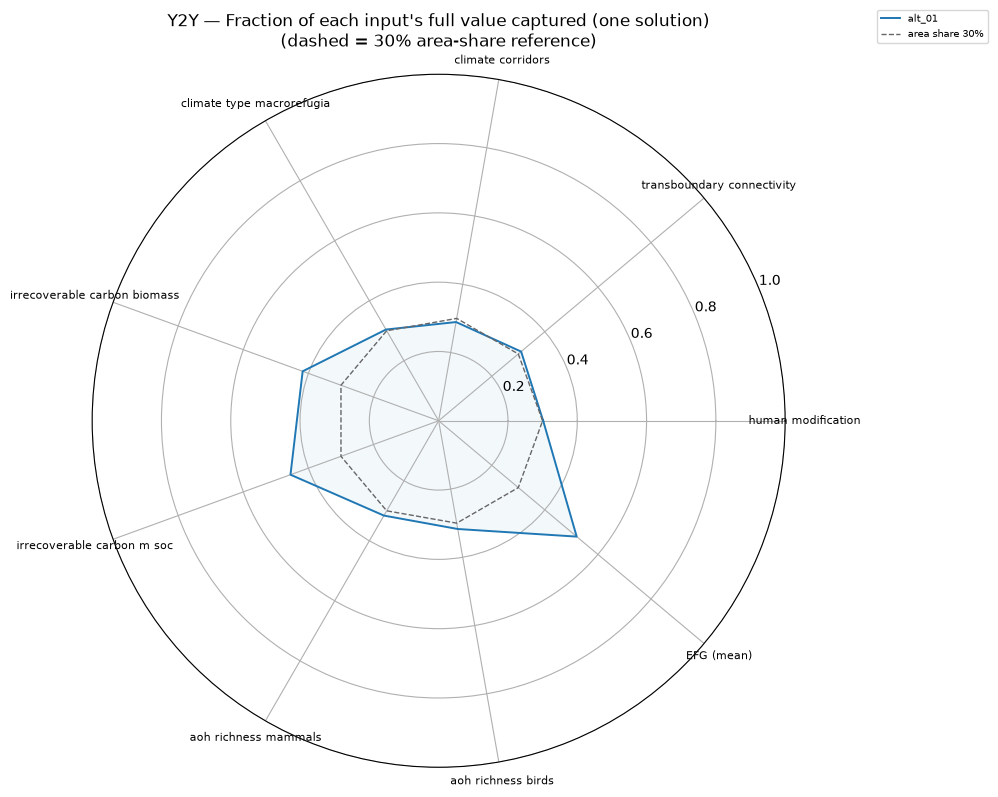

In [2]:
# ---- Radar: captured fraction per input vs the area-share ring ----
rc.radar(A)

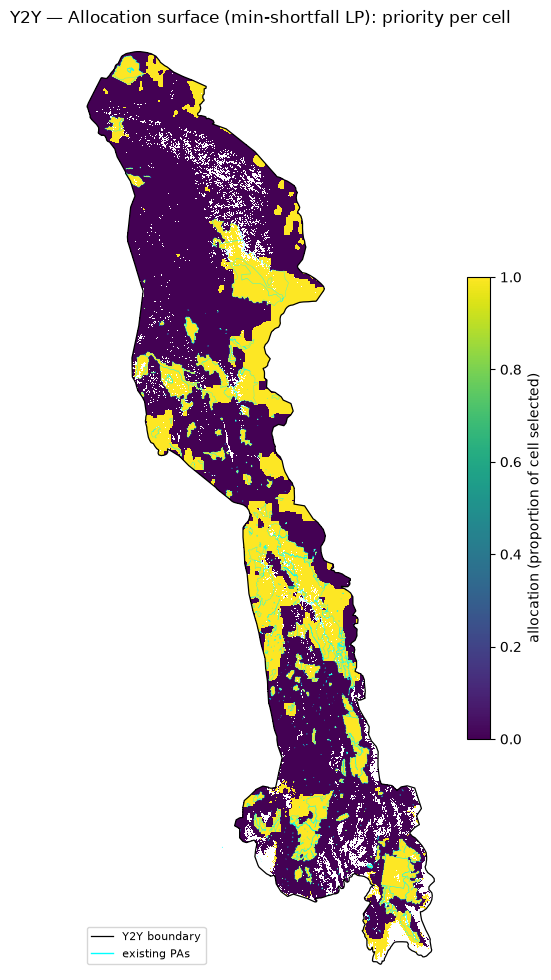

In [3]:
# ---- Allocation surface / selection-frequency map ----
rc.allocation_map(A)

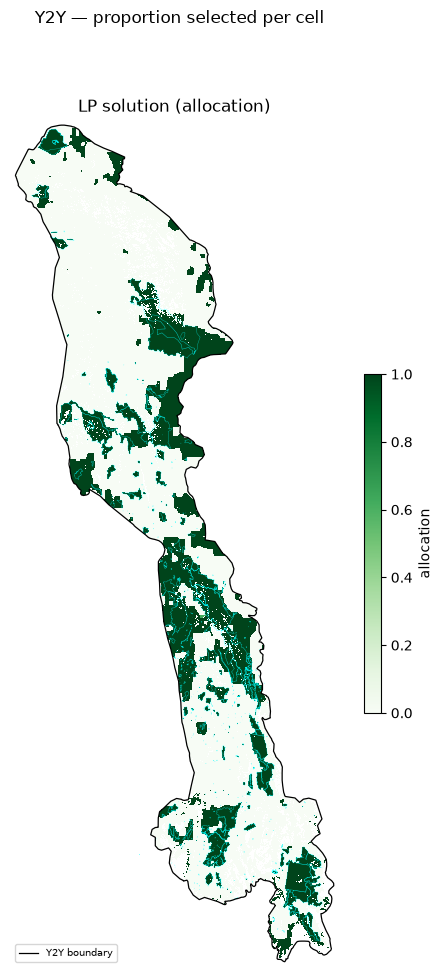

In [4]:
# ---- Solution map(s) ----
rc.solution_maps(A)

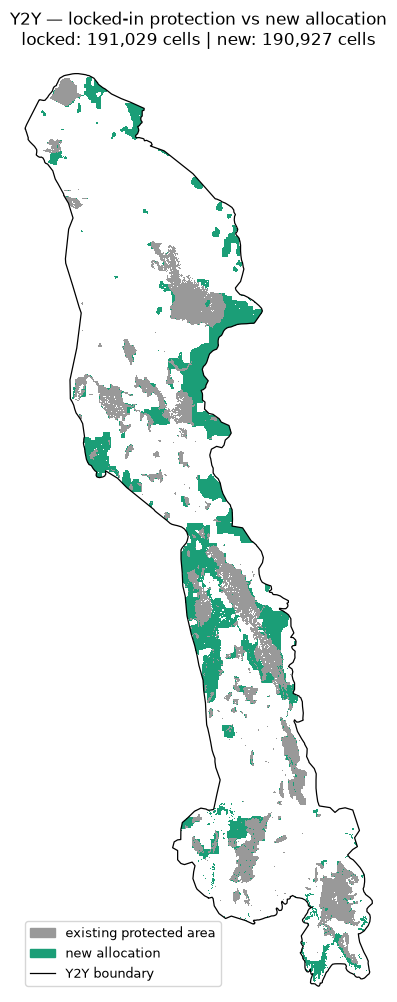

In [5]:
# ---- Existing protection vs new allocation ----
rc.existing_vs_new(A)

In [6]:
# ---- Trade-off table + headline stats ----
rc.tradeoff(A)

Per-solution summary:
alternative  n_selected  pct_region  n_added_beyond_pa
     alt_01    381874.2          30             190705

window planning units : 1,272,914
area budget (cells)   : 381,874 (30%)
locked-in             : 191,029 (15.0% of window)
area selected         : 30.0% of window


## Candidate areas vs the existing-protection benchmark

`build_stacks` loads the feature stacks, computes **full-Y2Y** region totals (so contribution / efficiency stay “% of Y2Y”), and profiles: the **NEW candidate areas** (connected blocks of new allocation) and the analysis' **benchmark** block (y2y: featured parks + Ross River; north_bc: the 4 IPCA anchors; ab_foothills: the existing in-window PAs). Each area gets three star-plot views + the consequences tables. Figures/CSVs → the run's folder.

**Naming & layout:** the new candidate areas are numbered **Option 1–N** in the order they are selected (the same numbers annotate `rc.new_map`); benchmark / manual areas keep their real names. The consequences tables split their columns into two groups — *Alternatives (new options)* vs *Established Protected/Priority Areas* — and every value prints to at least **2 significant figures** (small cells gain decimals rather than rounding to `0.0`).

In [7]:
# ---- Build stacks + profile NEW clusters + benchmark block (+ manual area) ----
rc.build_stacks(A)

  spread: 6 clusters over lat 42.6-66.5N
new candidate areas   : 1254 components, 6 kept (>= 25 cells, spread)
benchmark areas       : 6 profiled [named_pa]
cell size 1.0 km^2 | full-Y2Y PU denom = 1,272,914
shared efficiency scale EFF_RMAX = 0.30 %/1,000 km^2


<results y2y | iter6_y2y | 1286x3312 | 6 new clusters>

### Stated limitation — the human-footprint audit

`human_modification` enters the solve as intactness (`1 − gHM`). Over a uniformly wild region that
layer has **leverage 0.042** — its captured fraction is confined to 27.2–31.4 % whatever we select
— so it holds roughly **1 % of the objective's achievable swing** and cannot counterweight
anything. This cell quantifies what that costs.

Read the group breakdown carefully: the **whole-solution** mean looks reassuring only because the
locked-in protected areas are already very intact (existing parks sit in wild places). Split the
optimizer's *own* choices out and the sign reverses — the new allocation is **more** modified than
the land it declined. The cause is a confound rather than a modelling error: AOH richness peaks in
productive low-elevation valleys, which is also where people settle, so richness pulls the solution
toward modified land and nothing in the stack pulls back hard enough.

Published as a limitation by decision (2026-08-17). Restoring intactness would need either a role
change (gHM as a penalty or cost) or an aggressive nonlinearity — a p1–p99 stretch only reaches
0.084 — and both introduce a new uncalibrated dial into a map that already has too many.

In [ ]:
# ---- Human-footprint audit: does the solution actually avoid modified land? ----
rc.footprint_audit(A)

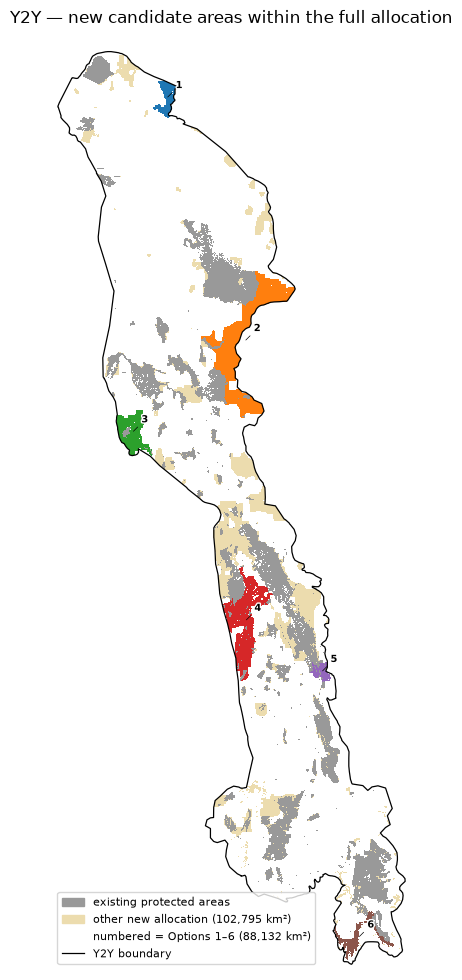

In [8]:
# ---- New candidate areas: map (colored, numbered) within the full allocation ----
rc.new_map(A)

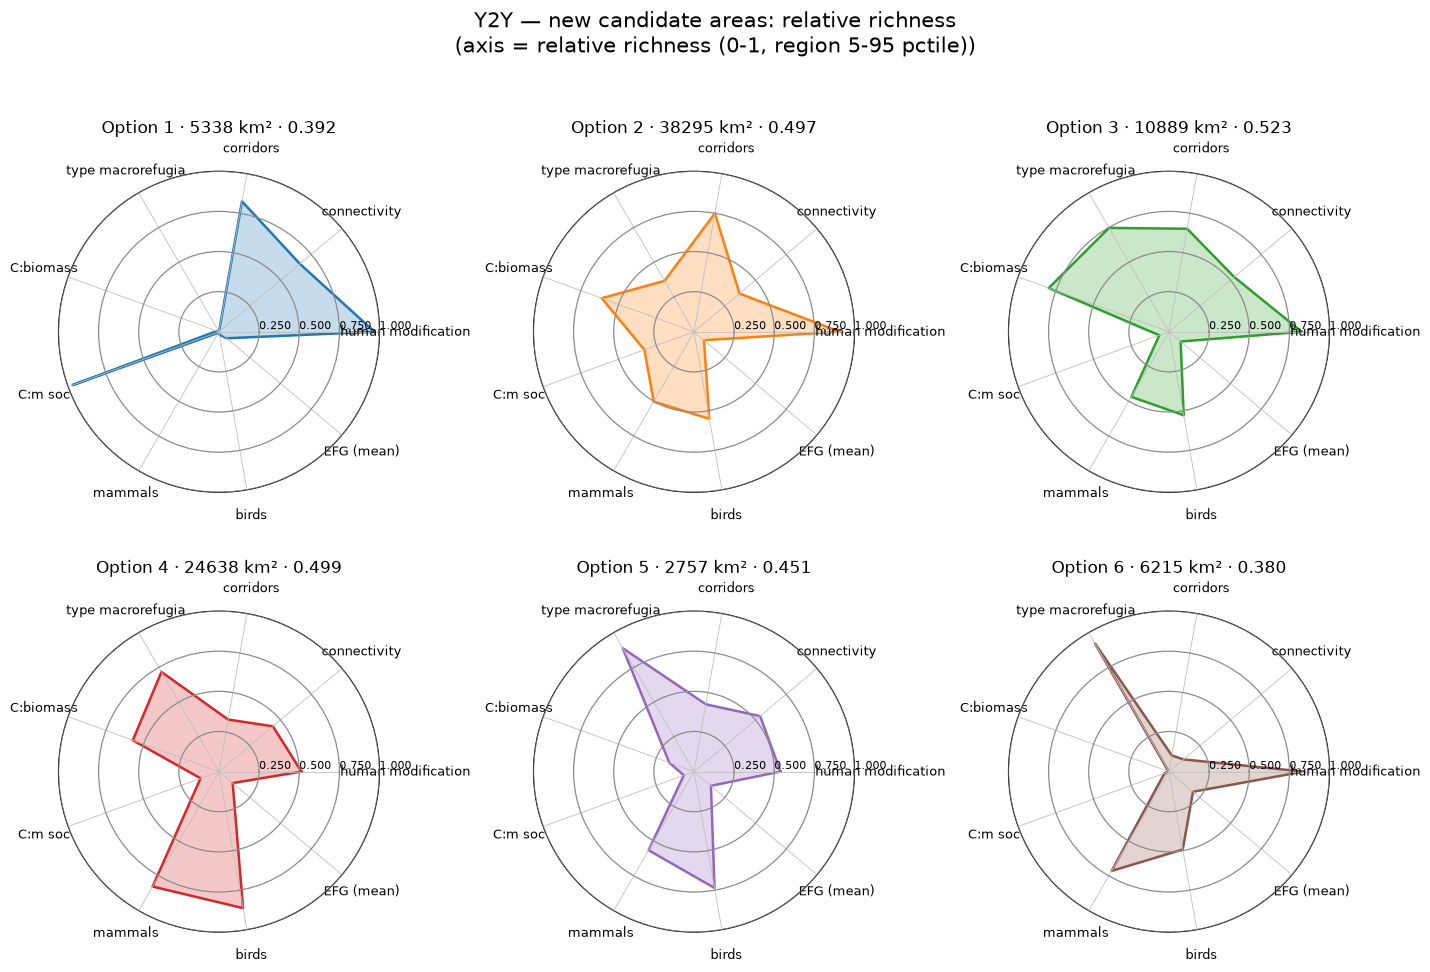

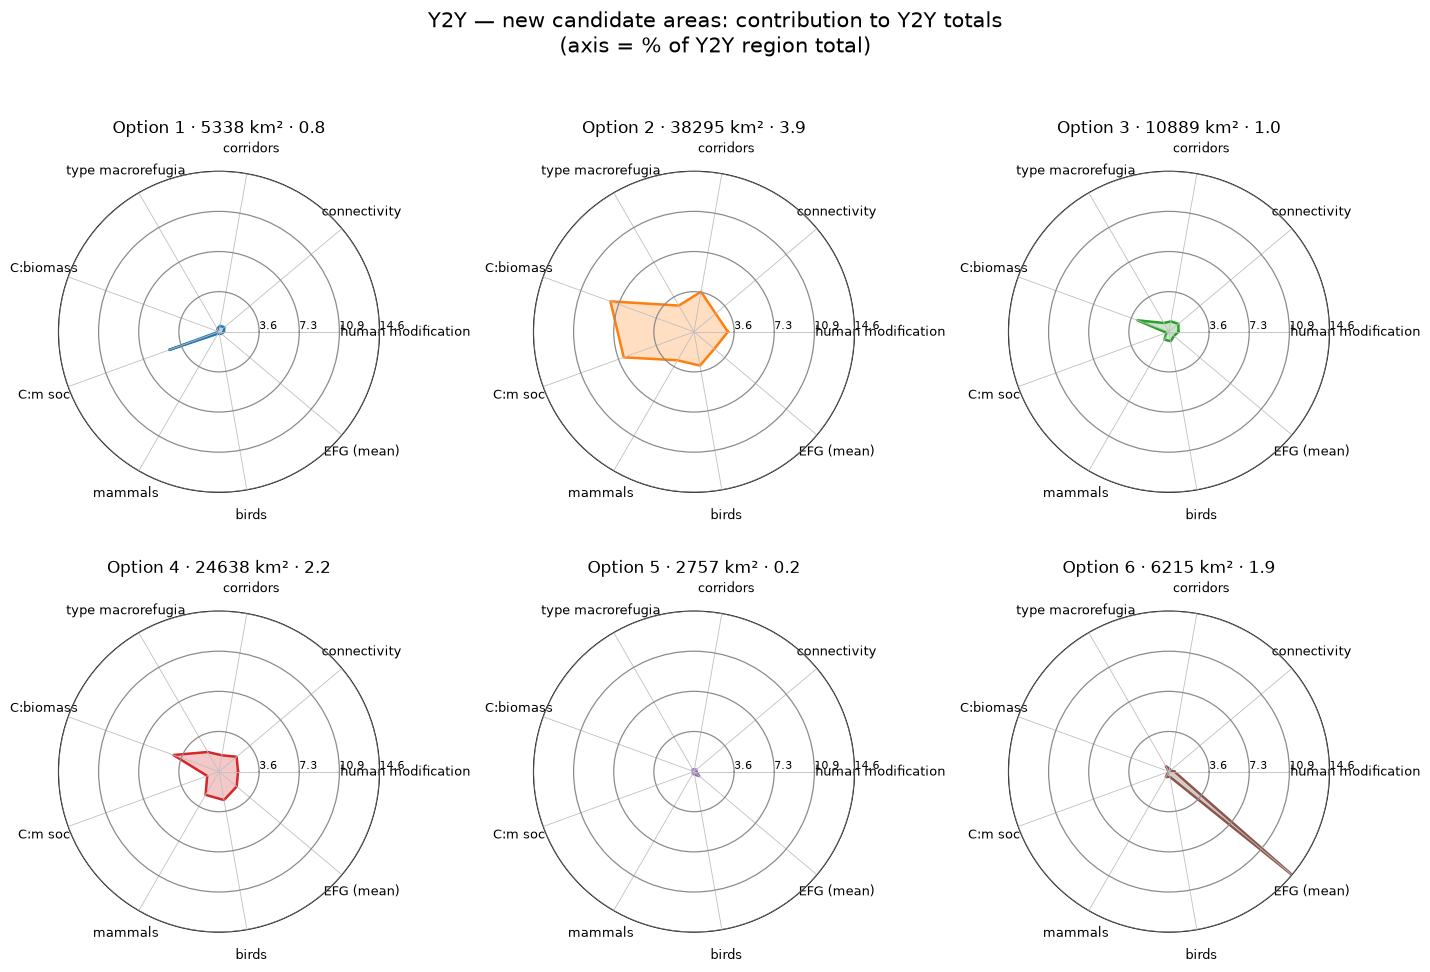

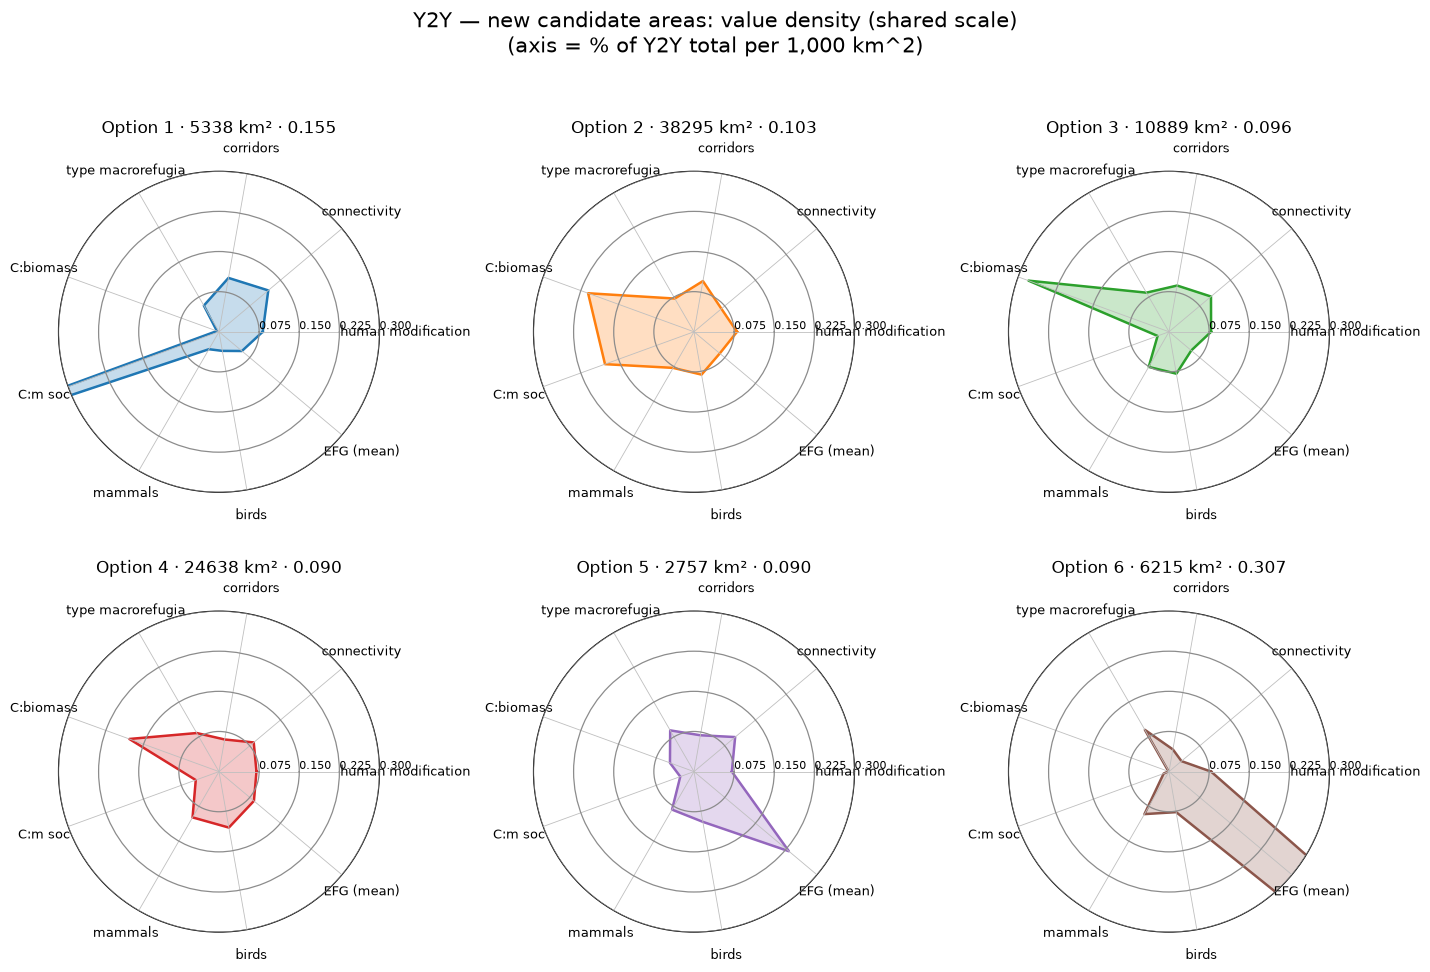

In [9]:
# ---- New candidate areas: 3 star-plot views (richness / contribution / efficiency) ----
rc.new_stars(A)

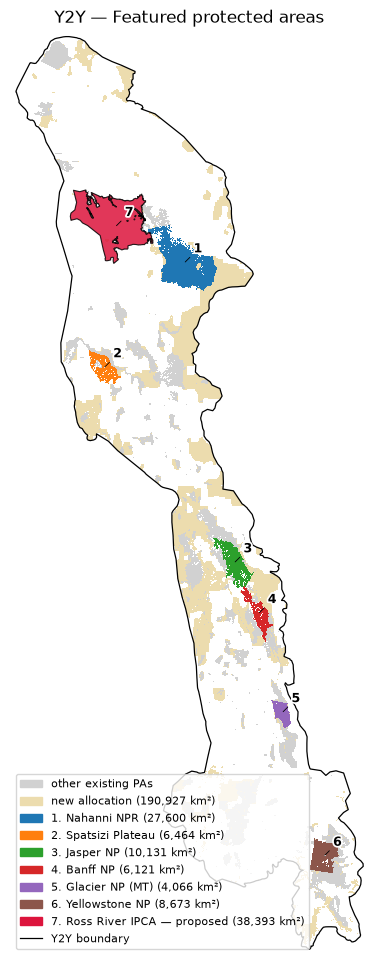

In [10]:
# ---- Benchmark areas: map ----
rc.bench_map(A)

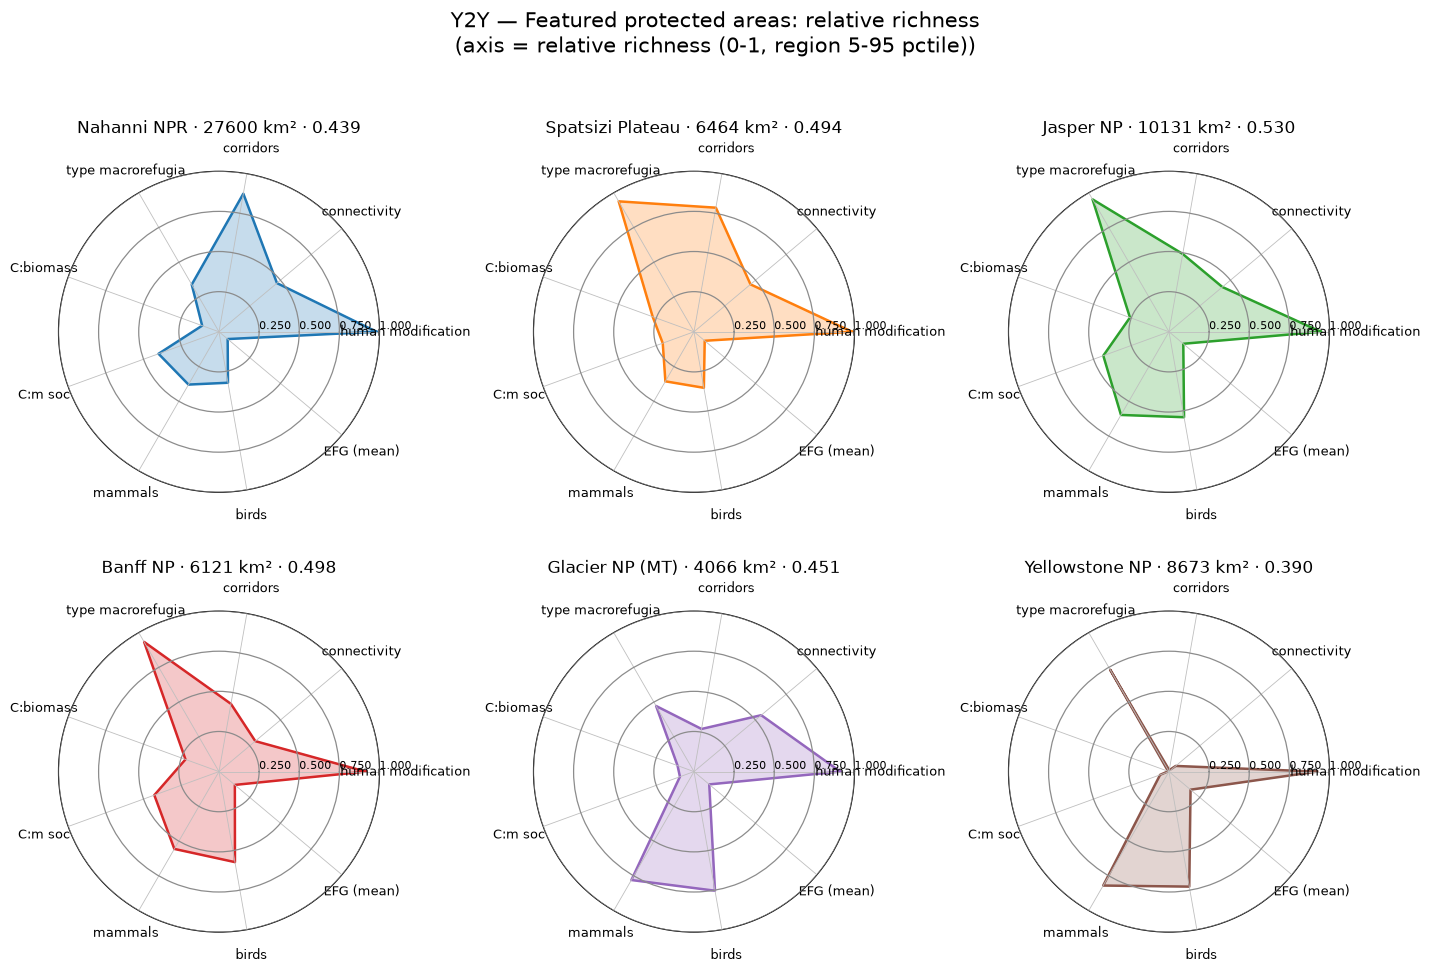

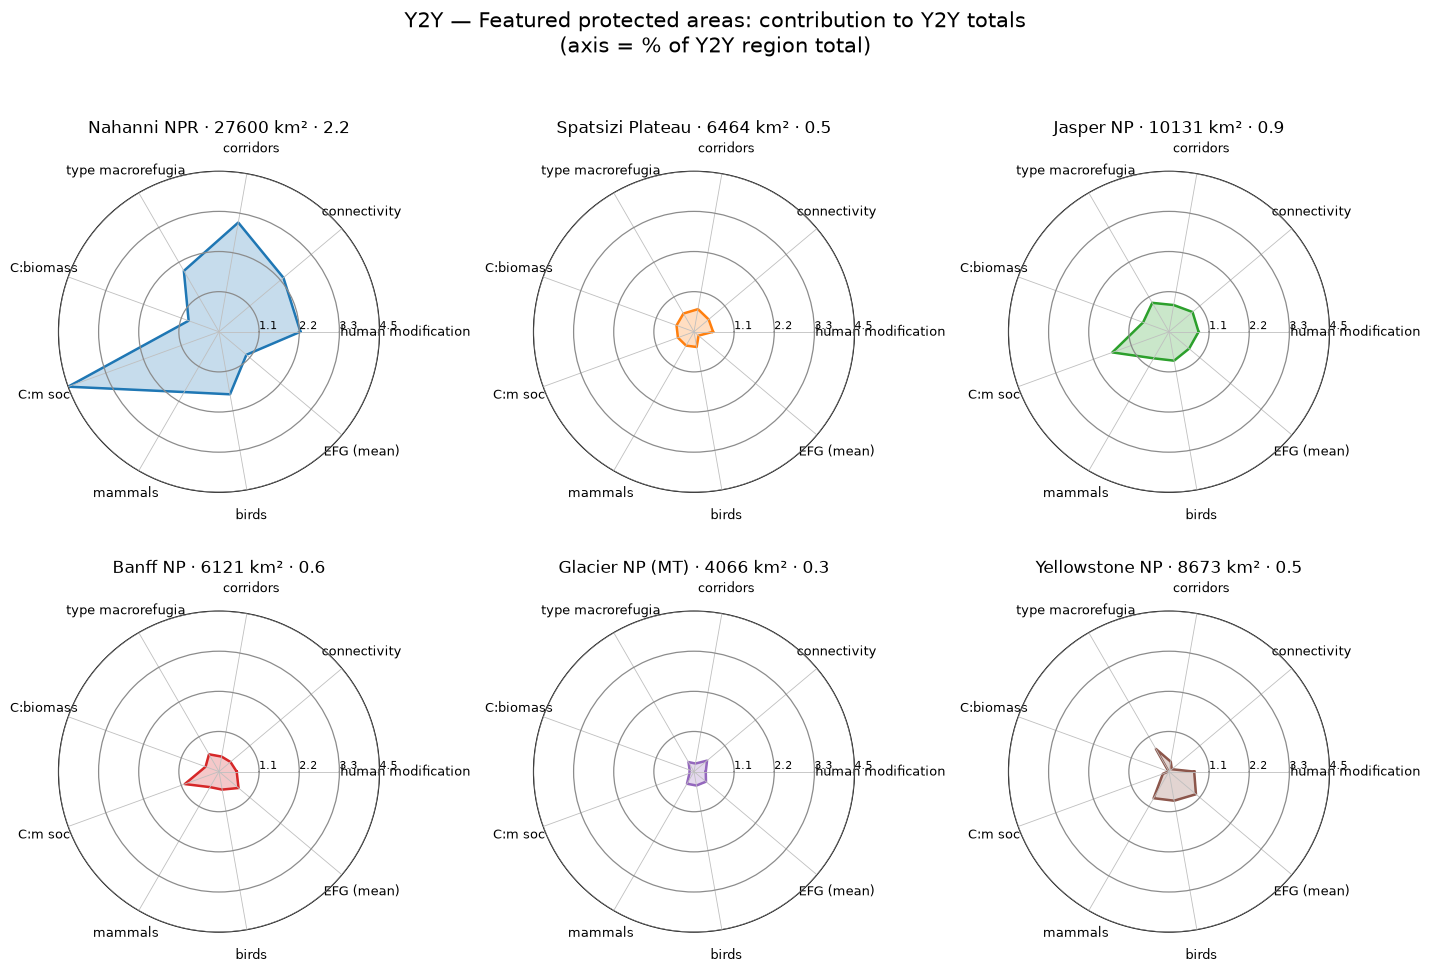

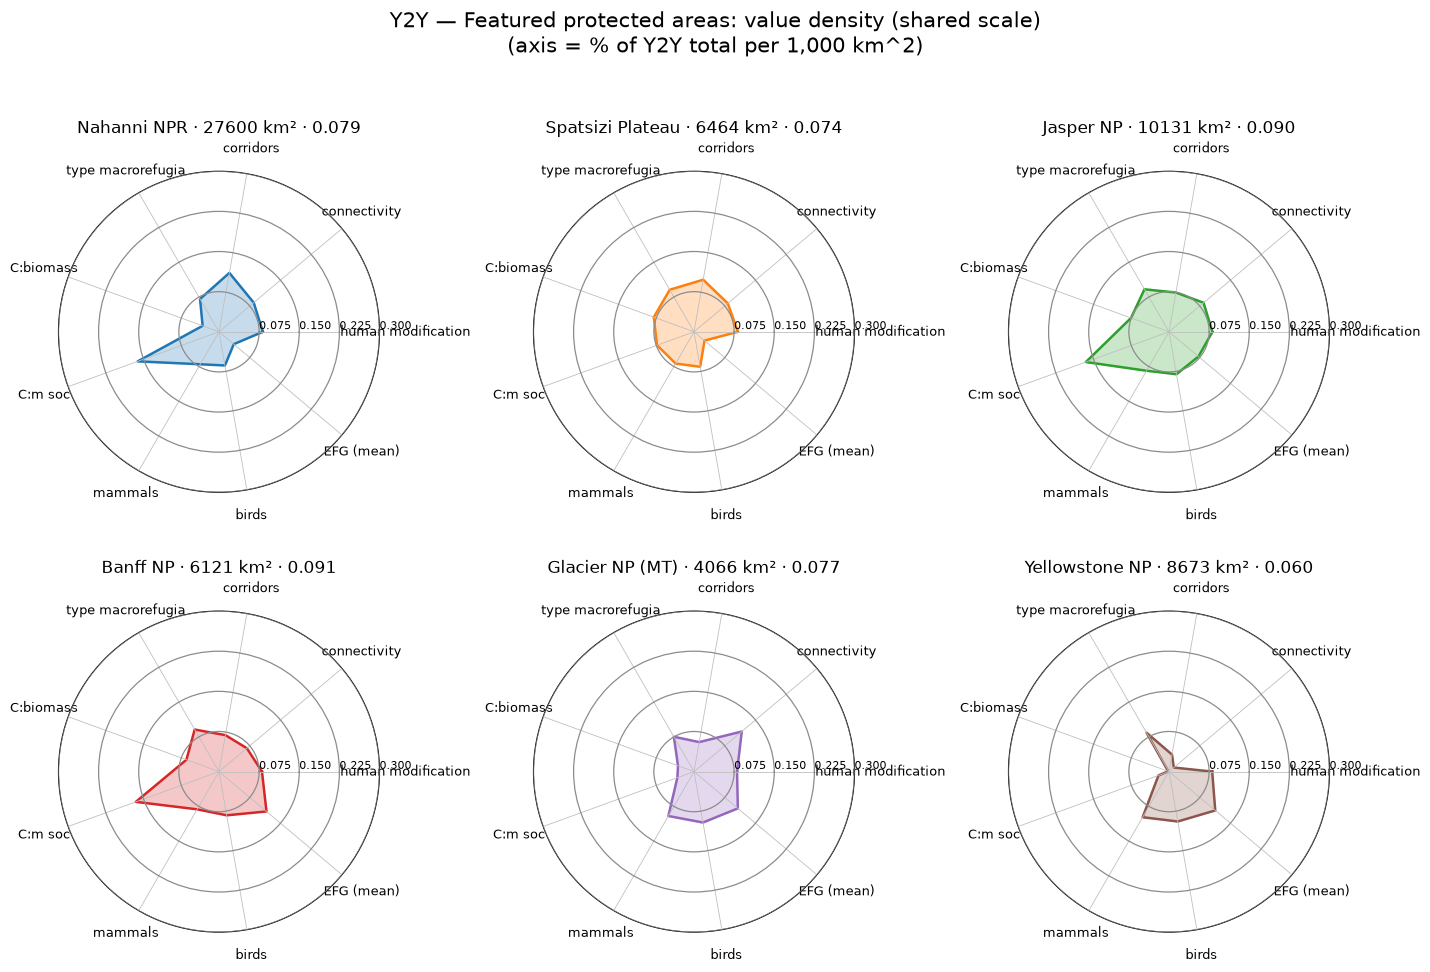

In [11]:
# ---- Benchmark areas: 3 star-plot views ----
rc.bench_stars(A)

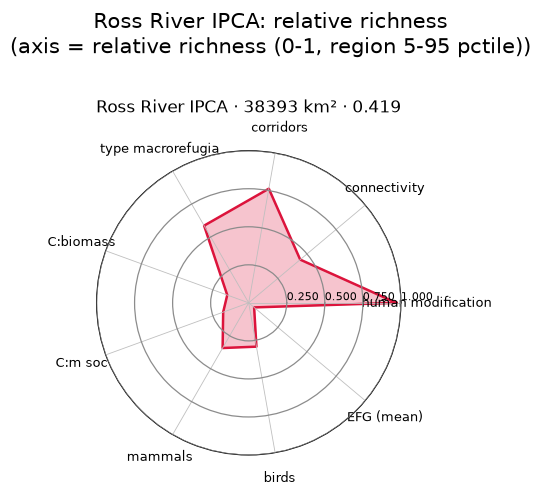

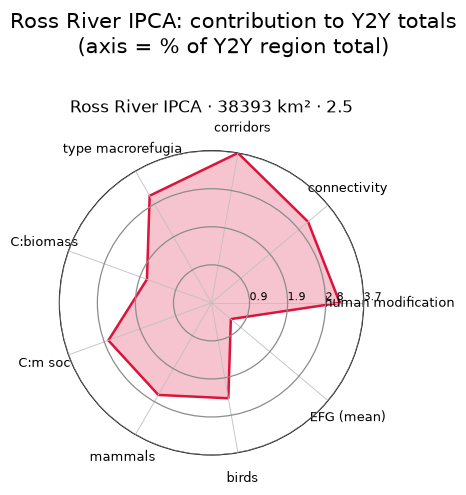

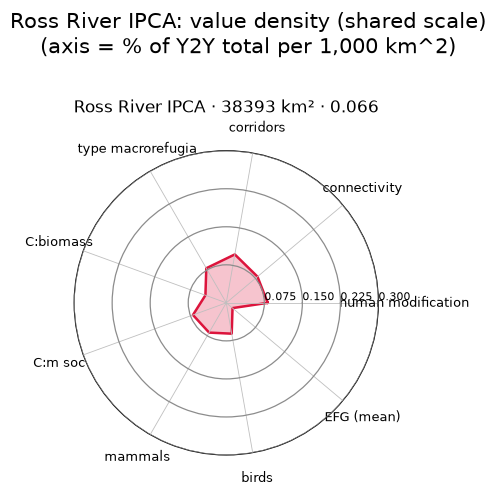

In [12]:
# ---- Manual area (Ross River for y2y; no-op for the sub-regions) ----
rc.manual_block(A)

In [13]:
# ---- Consequences: transposed decision matrices (contribution / efficiency / raw) ----
rc.consequences(A)

CONTRIBUTION (% of Y2Y total):
  Contribution = area's share of the Y2Y region-wide total per input (%). Rows: 2 area metrics + 9 inputs; columns: areas.
                       Alternatives (new options)                                              Established Protected/Priority Areas                                                                                   
                                         Option 1 Option 2 Option 3 Option 4 Option 5 Option 6                          Nahanni NPR Spatsizi Plateau Jasper NP Banff NP Glacier NP (MT) Yellowstone NP Ross River IPCA
area (km^2)                                 5,338   38,295   10,889   24,638    2,757    6,215                               27,600            6,464    10,131    6,121           4,066          8,673          38,393
area (% of Y2Y)                              0.42     3.01     0.86     1.94     0.22     0.49                                 2.17             0.51      0.80     0.48            0.32           0.68   

(                                                   Alternatives (new options)                                                    Established Protected/Priority Areas                                                                                   
                                                                      Option 1  Option 2  Option 3  Option 4  Option 5   Option 6                          Nahanni NPR Spatsizi Plateau Jasper NP Banff NP Glacier NP (MT) Yellowstone NP Ross River IPCA
 Contribution = area's share of the Y2Y region-w...                                                                                                                                                                                                      
 area (km^2)                                                          5338.000  38295.00  10889.00  24638.00  2757.000  6215.0000                             27600.00          6464.00  10131.00  6121.00         4066.00       8673.000        38393.00


In [14]:
# ---- Plain-language strongest / weakest summary per area ----
rc.plain_language(A)

Y2Y — per-area strongest / weakest inputs (by relative richness):

  [Alternatives (new options)]
  Option 1               strongest: Carbon: mineral soil, Intactness, Climate corridors   |   weakest: Climate refugia, Mammal richness, Carbon: biomass
  Option 2               strongest: Intactness, Climate corridors, Carbon: biomass   |   weakest: Ecosystem groups (EFG), Carbon: mineral soil, Climate refugia
  Option 3               strongest: Intactness, Carbon: biomass, Climate refugia   |   weakest: Carbon: mineral soil, Ecosystem groups (EFG), Mammal richness
  Option 4               strongest: Bird richness, Mammal richness, Climate refugia   |   weakest: Ecosystem groups (EFG), Carbon: mineral soil, Climate corridors
  Option 5               strongest: Climate refugia, Bird richness, Mammal richness   |   weakest: Carbon: mineral soil, Ecosystem groups (EFG), Carbon: biomass
  Option 6               strongest: Climate refugia, Intactness, Mammal richness   |   weakest: Carbon: bio

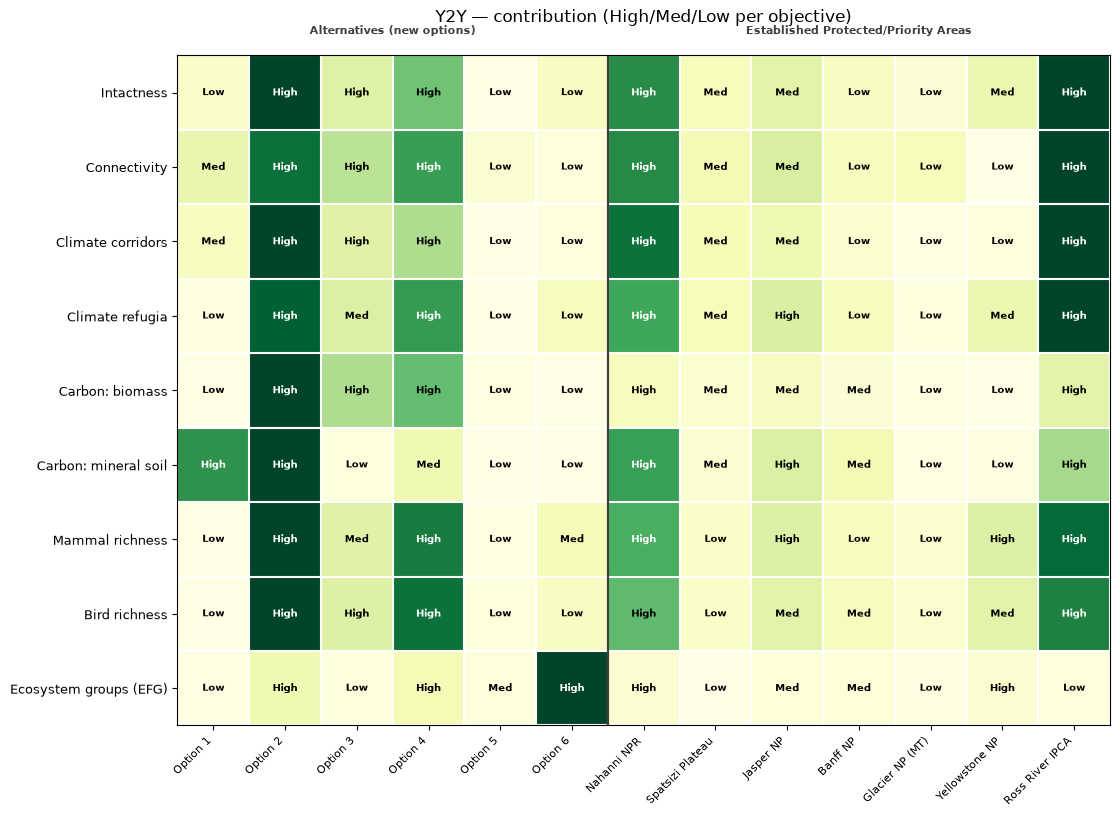

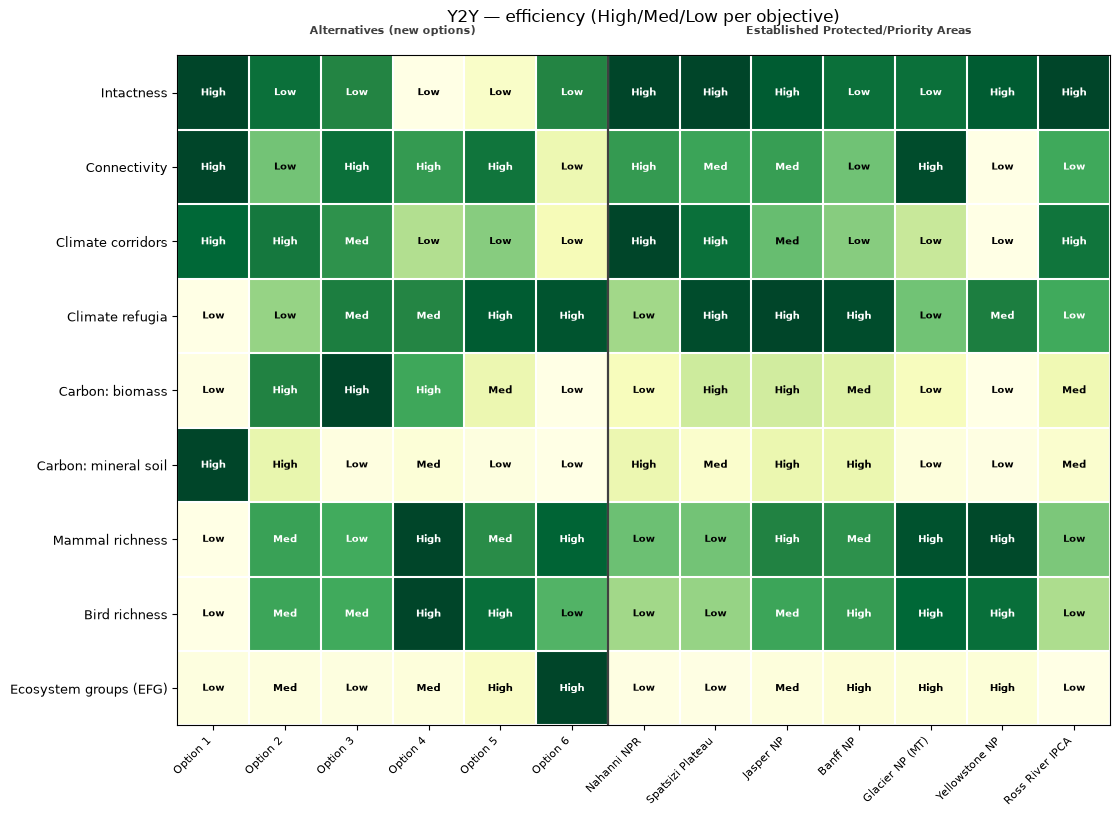

In [15]:
# ---- Colors-only High/Med/Low heatmaps (workshop / accessibility) ----
rc.heatmaps(A)